In [1]:
from agrifoodpy_data.land import UKCEH_LC_1000
from agrifoodpy import land 
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
from shapely.geometry import Point, MultiPoint

import xarray as xr

# Consolidated rasterised population dataset
The goal of this notebook is to generate a raster of local authority
population aligned with an input pixel map of the UK

The inputs used are
- Vector map of Counties and Unitary Authorities
- Population data for each of the unites defined above for England, Wales, Scotland and Northern Ireland
- Any raster map of the UK to pixelise the UK according to the British National Grid. The agrifoodpy-data package provides a few that can be useful. We use the land use map from CEH.  

## Population datasets

Population statistics are provided for each of the countries on separate datasets, often with slightly different metadata and formats.
Here we consolidate these datasets into a single geopandas dataframe which we will use to assign population values to each geometry element, and then to each pixel in the raster map

<Axes: >

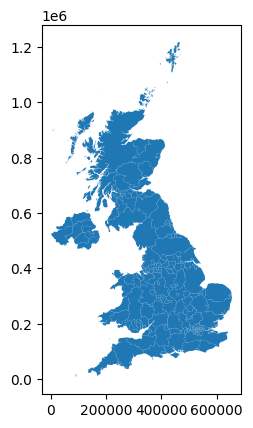

In [2]:
# Reading local authority boundaries.
LA_map_uk = gpd.read_file("data/Counties_and_Unitary_Authorities_December_2021_UK_BGC_2022_-4194855654272946208.gpkg")
LA_map_uk.plot()

In [3]:
LA_map_uk.head()

,CTYUA21CD,CTYUA21NM,CTYUA21NMW,BNG_E,BNG_N,LONG,LAT,GlobalID,geometry
0,E06000001,Hartlepool,,447160,531474,-1.27018,54.676102,{1FEF44F1-C688-448F-8566-47B9AA169146},"MULTIPOLYGON (((447097.001 537152.001, 446953...."
1,E06000002,Middlesbrough,,451141,516887,-1.21099,54.544701,{9C23D16E-FD69-4C12-84E8-BD741DFF540C},"MULTIPOLYGON (((449862.75 521262.4, 449381.8 5..."
2,E06000003,Redcar and Cleveland,,464361,519597,-1.00608,54.567501,{9A564496-C9C6-40A4-817B-C992B89F643F},"MULTIPOLYGON (((455939.672 527395.073, 455853...."
3,E06000004,Stockton-on-Tees,,444940,518183,-1.30664,54.556900,{D225D558-7BF7-4F62-A4CD-B23004FE28E9},"MULTIPOLYGON (((444126.099 528005.799, 444064...."
4,E06000005,Darlington,,428029,515648,-1.56835,54.535301,{BB565C9E-E3DE-4997-98BE-0A72541B5E21},"MULTIPOLYGON (((423475.701 524731.597, 423296...."


In [4]:
# England and Wales
LA_pop_eng = pd.read_csv("data/2617702922826067.csv", header=5, skipfooter=6, engine="python")
LA_pop_eng = LA_pop_eng.rename(columns={"2022 local authorities: county": "Area name",
                                        "mnemonic" : "Area code",
                                        "2021" : "Persons"})

# Northern Ireland
LA_pop_ire = pd.read_excel("data/census-2021-ms-a14-LGD.xlsx",
                           sheet_name="LGD",
                           header=5,
                           usecols=["Geography", "Geography code", "All usual residents"])

LA_pop_ire = LA_pop_ire.rename(columns={"Geography code": "Area code",
                                        "All usual residents":"Persons",
                                        "Geography": "Area name"})

# Scotland
LA_pop_sco = pd.read_excel("data/scotland-s-census-2022-first-results-rounded-population-estimates-data.xlsx",
                           sheet_name="Table 1",
                           header=3,
                           usecols=["Area name", "Area code", "All persons"],
                           skiprows=[4])

LA_pop_sco = LA_pop_sco.rename(columns={"All persons": "Persons"})

LA_pop_sco

,Area name,Area code,Persons
0,Aberdeen City,S12000033,224000
1,Aberdeenshire,S12000034,263900
2,Angus,S12000041,114400
3,Argyll and Bute,S12000035,86000
4,City of Edinburgh,S12000036,512700
5,Clackmannanshire,S12000005,51800
6,Dumfries and Galloway,S12000006,145900
7,Dundee City,S12000042,148100
8,East Ayrshire,S12000008,120300
9,East Dunbartonshire,S12000045,109000


In [5]:
# After renaming columns, we can concatenate all dataframes
LA_pop_uk = pd.concat([LA_pop_ire, LA_pop_eng, LA_pop_sco], ignore_index=True)
LA_pop_uk.head()

,Area name,Area code,Persons
0,Antrim and Newtownabbey,N09000001,145661
1,"Armagh City, Banbridge and Craigavon",N09000002,218656
2,Belfast,N09000003,345418
3,Causeway Coast and Glens,N09000004,141746
4,Derry City and Strabane,N09000005,150756


In [6]:
# Using the Area code to merge population data with the geodataframe
LA_data = LA_map_uk.merge(LA_pop_uk, right_on="Area code", left_on="CTYUA21CD", how="outer")
LA_data.head()

,CTYUA21CD,CTYUA21NM,CTYUA21NMW,BNG_E,BNG_N,LONG,LAT,GlobalID,geometry,Area name,Area code,Persons
0,E06000001,Hartlepool,,447160,531474,-1.27018,54.676102,{1FEF44F1-C688-448F-8566-47B9AA169146},"MULTIPOLYGON (((447097.001 537152.001, 446953....",Hartlepool,E06000001,92338
1,E06000002,Middlesbrough,,451141,516887,-1.21099,54.544701,{9C23D16E-FD69-4C12-84E8-BD741DFF540C},"MULTIPOLYGON (((449862.75 521262.4, 449381.8 5...",Middlesbrough,E06000002,143926
2,E06000003,Redcar and Cleveland,,464361,519597,-1.00608,54.567501,{9A564496-C9C6-40A4-817B-C992B89F643F},"MULTIPOLYGON (((455939.672 527395.073, 455853....",Redcar and Cleveland,E06000003,136531
3,E06000004,Stockton-on-Tees,,444940,518183,-1.30664,54.556900,{D225D558-7BF7-4F62-A4CD-B23004FE28E9},"MULTIPOLYGON (((444126.099 528005.799, 444064....",Stockton-on-Tees,E06000004,196595
4,E06000005,Darlington,,428029,515648,-1.56835,54.535301,{BB565C9E-E3DE-4997-98BE-0A72541B5E21},"MULTIPOLYGON (((423475.701 524731.597, 423296....",Darlington,E06000005,107799


<Axes: >

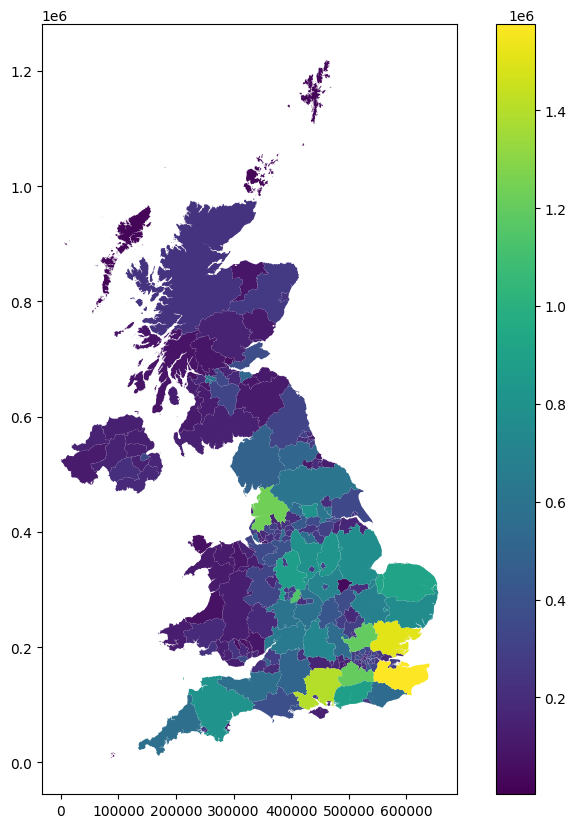

In [7]:
LA_data.plot("Persons", figsize=(10, 10), legend=True)

## Pixel map of the UK

We need any rasterised map of the UK with pixels aligned to the British National Grid.
The agrifoodpy-data package contains a few we can use. Data contained in those is not important, as long as the coordinate system is aligned with the raster map we want to generate.

<Axes: >

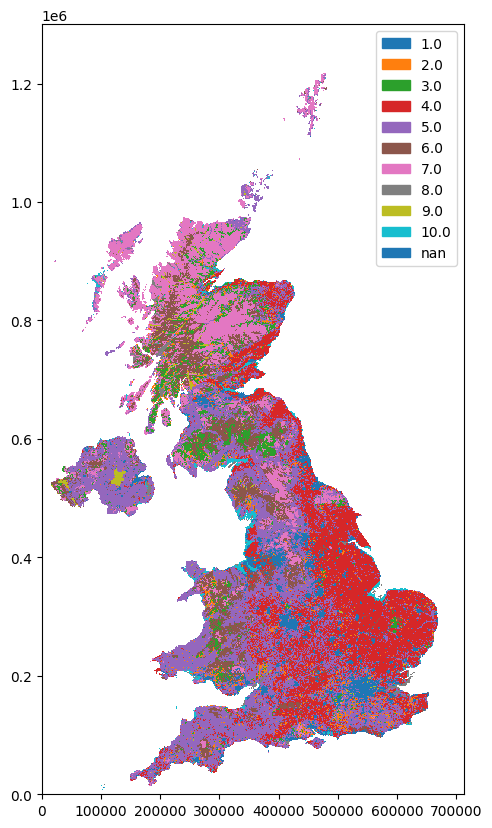

In [8]:
land_use_uk = UKCEH_LC_1000["dominant_aggregate"]

f, ax = plt.subplots(figsize=(10, 10))
land_use_uk.land.plot(ax=ax)

In [9]:
# Create a name dictionary
LA_names = np.unique(LA_data['Area name'])
name_dict = dict(zip(LA_names, np.arange(len(LA_names))))
print(name_dict)

{'Aberdeen City': np.int64(0), 'Aberdeenshire': np.int64(1), 'Angus': np.int64(2), 'Antrim and Newtownabbey': np.int64(3), 'Ards and North Down': np.int64(4), 'Argyll and Bute': np.int64(5), 'Armagh City, Banbridge and Craigavon': np.int64(6), 'Barking and Dagenham': np.int64(7), 'Barnet': np.int64(8), 'Barnsley': np.int64(9), 'Bath and North East Somerset': np.int64(10), 'Bedford': np.int64(11), 'Belfast': np.int64(12), 'Bexley': np.int64(13), 'Birmingham': np.int64(14), 'Blackburn with Darwen': np.int64(15), 'Blackpool': np.int64(16), 'Blaenau Gwent': np.int64(17), 'Bolton': np.int64(18), 'Bournemouth, Christchurch and Poole': np.int64(19), 'Bracknell Forest': np.int64(20), 'Bradford': np.int64(21), 'Brent': np.int64(22), 'Bridgend': np.int64(23), 'Brighton and Hove': np.int64(24), 'Bristol, City of': np.int64(25), 'Bromley': np.int64(26), 'Buckinghamshire': np.int64(27), 'Bury': np.int64(28), 'Caerphilly': np.int64(29), 'Calderdale': np.int64(30), 'Cambridgeshire': np.int64(31), 'Ca

In [ ]:
# Create a grid of points from the land use data
xcoords = land_use_uk.x.values
ycoords = land_use_uk.y.values

sizex = land_use_uk.shape[1]
sizey = land_use_uk.shape[0]

# Fill the grid positions and indexes
xxpos = np.tile(xcoords, len(ycoords))
ix = np.tile(np.arange(sizex), sizey)
yypos = np.repeat(ycoords, len(xcoords))
iy = np.repeat(np.arange(sizey), sizex)

# Generate an empty dataframe with the positions of the pixels and an identifying index
df = pd.DataFrame({'xpos':ix, 'ypos':iy})
df['geometry'] = list(zip(xxpos,yypos))
df['geometry'] = df['geometry'].apply(Point)

points = gpd.GeoDataFrame(df, crs='EPSG:27700')
points.head()

,xpos,ypos,geometry
0,0,0,POINT (500 500)
1,1,0,POINT (1500 500)
2,2,0,POINT (2500 500)
3,3,0,POINT (3500 500)
4,4,0,POINT (4500 500)


In [11]:
# For each point in the grid dataframe, find which LA it falls in. 

pointInPolys = gpd.tools.sjoin(points, LA_data, predicate="within", how='inner')
pointInPolys['LA index'] = np.array([name_dict[g] for g in pointInPolys['Area name']])
pointInPolys

,xpos,ypos,geometry,index_right,CTYUA21CD,CTYUA21NM,CTYUA21NMW,BNG_E,BNG_N,LONG,LAT,GlobalID,Area name,Area code,Persons,LA index
5079,88,7,POINT (88500 7500),49,E06000053,Isles of Scilly,,91327,11447,-6.30217,49.923302,{0D0AE731-A0B0-4D36-9212-372702F77102},Isles of Scilly,E06000053,2053,94
7220,90,10,POINT (90500 10500),49,E06000053,Isles of Scilly,,91327,11447,-6.30217,49.923302,{0D0AE731-A0B0-4D36-9212-372702F77102},Isles of Scilly,E06000053,2053,94
7221,91,10,POINT (91500 10500),49,E06000053,Isles of Scilly,,91327,11447,-6.30217,49.923302,{0D0AE731-A0B0-4D36-9212-372702F77102},Isles of Scilly,E06000053,2053,94
7934,91,11,POINT (91500 11500),49,E06000053,Isles of Scilly,,91327,11447,-6.30217,49.923302,{0D0AE731-A0B0-4D36-9212-372702F77102},Isles of Scilly,E06000053,2053,94
7935,92,11,POINT (92500 11500),49,E06000053,Isles of Scilly,,91327,11447,-6.30217,49.923302,{0D0AE731-A0B0-4D36-9212-372702F77102},Isles of Scilly,E06000053,2053,94
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
867472,464,1216,POINT (464500 1216500),177,S12000027,Shetland Islands,,434516,1180307,-1.37344,60.505001,{1327D562-2F27-4189-A6C0-1E380E3C441E},Shetland Islands,S12000027,22900,164
867473,465,1216,POINT (465500 1216500),177,S12000027,Shetland Islands,,434516,1180307,-1.37344,60.505001,{1327D562-2F27-4189-A6C0-1E380E3C441E},Shetland Islands,S12000027,22900,164
868181,460,1217,POINT (460500 1217500),177,S12000027,Shetland Islands,,434516,1180307,-1.37344,60.505001,{1327D562-2F27-4189-A6C0-1E380E3C441E},Shetland Islands,S12000027,22900,164
868182,461,1217,POINT (461500 1217500),177,S12000027,Shetland Islands,,434516,1180307,-1.37344,60.505001,{1327D562-2F27-4189-A6C0-1E380E3C441E},Shetland Islands,S12000027,22900,164


In [ ]:
LA_grid_name = np.ones(land_use_uk.shape)*np.nan
LA_grid_pop = np.ones(land_use_uk.shape)*np.nan

# Fill the array with the LA ID on the corresponding index
LA_grid_name[tuple([pointInPolys['ypos'], pointInPolys['xpos']])] = pointInPolys['LA index']
LA_grid_pop[tuple([pointInPolys['ypos'], pointInPolys['xpos']])] = pointInPolys['Persons']


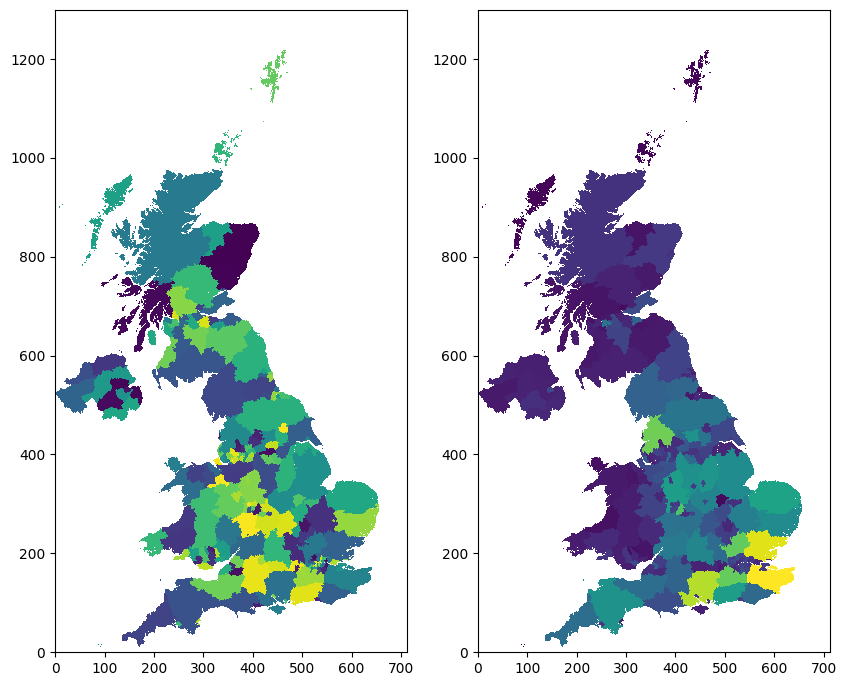

In [ ]:
# Plot the rasterised data.

f, ax = plt.subplots(1, 2, figsize=(10,10))
ax[0].imshow(LA_grid_name, interpolation='none', origin='lower')
ax[1].imshow(LA_grid_pop, interpolation='none', origin='lower')

# Chart on the left shows the local authority index, while the chart on the right shows the population per local authority.

In [ ]:
# Convert the arrays to xarray DataArrays

LA_region_map = xr.DataArray(
    data=LA_grid_name,
    dims=['y', 'x'],
    coords={'x': xcoords, 'y': ycoords},
    attrs=name_dict,
    name="Region"
)
LA_region_map

<xarray.DataArray 'Region' (y: 1300, x: 713)> Size: 7MB
array([[nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       ...,
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan]], shape=(1300, 713))
Coordinates:
  * y        (y) float64 10kB 500.0 1.5e+03 2.5e+03 ... 1.298e+06 1.3e+06
  * x        (x) float64 6kB 500.0 1.5e+03 2.5e+03 ... 7.115e+05 7.125e+05
Attributes: (12/217)
    Aberdeen City:                         0
    Aberdeenshire:                         1
    Angus:                                 2
    Antrim and Newtownabbey:               3
    Ards and North Down:                   4
    Argyll and Bute:                       5
    ...                                    ...
    Wirral:                                211
    Wokingham:                             212
    Wolverhampton:                         213
    Worcestershire:                        214
    Wrexham:                               215
    York:                                  216

In [15]:
LA_pop_map = xr.DataArray(
    data=LA_grid_pop,
    dims=['y', 'x'],
    coords={'x': xcoords, 'y': ycoords},
    name="Population",
)
LA_pop_map

<xarray.DataArray 'Population' (y: 1300, x: 713)> Size: 7MB
array([[nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       ...,
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan]], shape=(1300, 713))
Coordinates:
  * y        (y) float64 10kB 500.0 1.5e+03 2.5e+03 ... 1.298e+06 1.3e+06
  * x        (x) float64 6kB 500.0 1.5e+03 2.5e+03 ... 7.115e+05 7.125e+05

In [16]:
LA_pop_arr = xr.DataArray(
    data=LA_pop_uk["Persons"],
    coords={"Region":LA_pop_uk["Area name"]},
    name="Population")

LA_pop_arr

<xarray.DataArray 'Population' (Region: 217)> Size: 2kB
array([ 145661,  218656,  345418,  141746,  150756,  116812,  149106,
        138994,  150293,  182074,  163659,  107799,  522068,   92338,
        143926,  320567,  136531,  196595,  196151,  300125,  208967,
        147776,  274172,  154738,  141036,  398772,  357150,  128478,
        210974,  499846,  295963,  193851,  551938,  242088,  223773,
        269923,  294773,  231071,  235052,  329330, 1235354,  154519,
        486088,  279233,  183248,  320199,  342215,  267014,  156966,
        169680,  202821,  615491,  244572,  308106,  265807,  556521,
        546412,  206631,  433216,  811956,  353368,  261364,  368571,
        323632,   41049,  794636,  712366,  768364,  824822,  359525,
        425725,  187034,  323606,  258366,  185541,  876104,  596772,
       1144919,  345325,  323486,  341832,  216240,  284124,  263727,
        603676,  185225,  294252,  225262,  215671,  180686,  176001,
        678849, 1503524, 1198798,  916120,  760688,  210136,    8583,
        259146,  183157,  264238,  216589,  143375,  317654,  300553,
        351036,  307637,  310306,  327506,  204236,  218869,  389344,
        246472,  339816,  329992,  390719,  367115,  329984,  289068,
        261203,  262052,  305909,  288181,  168063,  215186,  310260,
        195278,  209639,  278426,  124607,  277103,  140459,  279773,
        287060,  208003,  174224,  158500,  248922,  161448,  153496,
        177503,  553078,  545848, 1400899, 1576069,  725291, 1203108,
        882674,  193409,  472465,  570305,    2053,  216726,  264695,
        400196,  290424,  233407,  139324,  510333,  811640,  379579,
        645076,  571548,   68878,  117393,  114741,   95817,  154962,
        135117,  133169,   71475,  123360,  187897,  238490,  142289,
        145488,  131939,  362308,  237651,   58836,  175952,   66904,
         92276,   92957,  159592,  224000,  263900,  114400,   86000,
        512700,   51800,  145900,  148100,  120300,  109000,  112300,
         96800,  158400,  370400,  620700,  235400,   78400,   96600,
         93400,   26200,  133400,  341000,   22000,  150800,  183800,
        116900,   22900,  111600,  327200,   92600,   88400,  181300])
Coordinates:
  * Region   (Region) object 2kB 'Antrim and Newtownabbey' ... 'West Lothian'

In [17]:
# Save to file
encoding_reg = {"Region":{"dtype":"float32", "zlib": True, "complevel": 5}}
LA_region_map.to_netcdf("data/LA_region_map.nc", encoding=encoding_reg)

encoding_pop = {"Population":{"dtype":"float32", "zlib": True, "complevel": 5}}
LA_pop_map.to_netcdf("data/LA_pop_map.nc", encoding=encoding_pop)

LA_pop_arr.to_netcdf("data/LA_pop_arr.nc")